In [3]:
# Install necessary libraries (if not already installed in Colab)
# Install necessary libraries (if not already installed in Colab)
!pip install nltk scikit-learn pandas rake-nltk keybert sentence-transformers

import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from rake_nltk import Rake
# from keybert import KeyBERT # Keep this commented until you run cell 3c

# --- FIX: Ensure ALL required NLTK resources are downloaded ---
try:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
    # The resource causing the LookupError:
    nltk.download('punkt_tab')
    # Also add the tagger, which is often required for wordnet/lemmatization/POS tagging
    nltk.download('averaged_perceptron_tagger')
except LookupError as e:
    print(f"NLTK Download Error: {e}")


# --- Data Loading (Using a Sample for Demonstration) ---
data = {
    'document': [
        "Google is working on a new artificial intelligence model called Gemini.",
        "The quick brown fox jumps over the lazy dog in the field.",
        "New research suggests that solar power generation is now cheaper than coal power generation.",
        "The financial report detailed rising profits for the company.",
        "Scientists discovered a massive new exoplanet circling a distant star."
    ]
}
df = pd.DataFrame(data)

print("Setup Complete. All NLTK resources downloaded.")
print(f"Total documents loaded: {len(df)}")
print(df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Setup Complete. All NLTK resources downloaded.
Total documents loaded: 5
                                            document
0  Google is working on a new artificial intellig...
1  The quick brown fox jumps over the lazy dog in...
2  New research suggests that solar power generat...
3  The financial report detailed rising profits f...
4  Scientists discovered a massive new exoplanet ...


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [4]:
#Textprepeocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, remove_stopwords=True):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove punctuation (basic removal)
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Lemmatization (optional, but good practice)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    if remove_stopwords:
        # 5. Stopword Removal (for TF-IDF input)
        tokens = [word for word in tokens if word not in stop_words]

    # Rejoin tokens into a single string
    return " ".join(tokens)

# --- Create the two required columns ---

# Version 1: WITH Stopwords (Input for RAKE/KeyBERT, as they need context/delimiters)
df['text_with_stopwords'] = df['document'].apply(lambda x: preprocess_text(x, remove_stopwords=False))

# Version 2: WITHOUT Stopwords (Input for TF-IDF, as it needs filtered words)
df['text_without_stopwords'] = df['document'].apply(lambda x: preprocess_text(x, remove_stopwords=True))

print("\n--- Preprocessing Check ---")
print(f"Original Text:\t\t{df.iloc[0]['document']}")
print(f"TF-IDF Input (No Stopwords): {df.iloc[0]['text_without_stopwords']}")
print(f"RAKE/KeyBERT Input (With Stopwords): {df.iloc[0]['text_with_stopwords']}")


--- Preprocessing Check ---
Original Text:		Google is working on a new artificial intelligence model called Gemini.
TF-IDF Input (No Stopwords): google working new artificial intelligence model called gemini
RAKE/KeyBERT Input (With Stopwords): google is working on a new artificial intelligence model called gemini


In [5]:
#Keyword extraction Technique
#a.TF IDF scores
# 1. Initialize TF-IDF Vectorizer
# We use the already cleaned text (Version 2: without stopwords)
tfidf_vectorizer = TfidfVectorizer()

# 2. Fit and Transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_without_stopwords'])
feature_names = tfidf_vectorizer.get_feature_names_out()

# 3. Extract Top N (N=3) Keywords per document
N = 3
tfidf_keywords = []

for i in range(tfidf_matrix.shape[0]):
    # Get vector for current document
    doc_vector = tfidf_matrix[i, :]

    # Sort and get top N indices
    sorted_indices = doc_vector.toarray().argsort()[0, ::-1]
    top_indices = sorted_indices[:N]

    # Get the actual words and their scores
    keywords = [(feature_names[idx], doc_vector[0, idx]) for idx in top_indices]
    tfidf_keywords.append(keywords)

df['keywords_tfidf'] = tfidf_keywords
print("\n--- TF-IDF Keywords ---")
print(df[['document', 'keywords_tfidf']].head())



--- TF-IDF Keywords ---
                                            document  \
0  Google is working on a new artificial intellig...   
1  The quick brown fox jumps over the lazy dog in...   
2  New research suggests that solar power generat...   
3  The financial report detailed rising profits f...   
4  Scientists discovered a massive new exoplanet ...   

                                      keywords_tfidf  
0  [(working, 0.3664082043739687), (google, 0.366...  
1  [(jump, 0.3779644730092272), (lazy, 0.37796447...  
2  [(power, 0.5453720173013064), (generation, 0.5...  
3  [(profit, 0.40824829046386296), (report, 0.408...  
4  [(star, 0.3664082043739687), (massive, 0.36640...  


In [6]:
#Keyword Extraction Technique
#b.RAKE EXTRACTION
# 1. Initialize RAKE
r = Rake()
# Note: RAKE handles its own stopword removal and delimiting internally.

# 2. Extract Top N (N=3) Keyphrases per document
N = 3
rake_keyphrases = []

for text in df['text_with_stopwords']:
    # Extract keyphrases with scores
    r.extract_keywords_from_text(text)
    ranked_phrases_with_scores = r.get_ranked_phrases_with_scores()

    # Get top N phrases
    top_phrases = [(phrase, score) for score, phrase in ranked_phrases_with_scores[:N]]
    rake_keyphrases.append(top_phrases)

df['keyphrases_rake'] = rake_keyphrases
print("\n--- RAKE Keyphrases ---")
print(df[['document', 'keyphrases_rake']].head())


--- RAKE Keyphrases ---
                                            document  \
0  Google is working on a new artificial intellig...   
1  The quick brown fox jumps over the lazy dog in...   
2  New research suggests that solar power generat...   
3  The financial report detailed rising profits f...   
4  Scientists discovered a massive new exoplanet ...   

                                     keyphrases_rake  
0  [(new artificial intelligence model called gem...  
1  [(quick brown fox jump, 16.0), (lazy dog, 4.0)...  
2  [(solar power generation, 9.0), (new research ...  
3  [(financial report detailed rising profit, 25....  
4  [(massive new exoplanet circling, 16.0), (scie...  


In [7]:
#Keyword Extraction Technique
#c.keyBERT extraction(Embedding based)
# 1. Initialize KeyBERT (This can take a moment)
# We use Version 1 (with stopwords) as KeyBERT is context-dependent.
kw_model = KeyBERT()

# 2. Extract Top N (N=3) phrases per document
keybert_phrases = []

# KeyBERT is slower, so we'll use a small batch
for text in df['text_with_stopwords']:
    # The extract_keywords function handles the ranking based on similarity
    keywords = kw_model.extract_keywords(
        docs=text,
        keyphrase_ngram_range=(1, 3), # allows single words up to 3-word phrases
        stop_words=None, # stopwords were removed in our input, but KeyBERT can handle them if present
        top_n=N
    )
    keybert_phrases.append(keywords)

df['keyphrases_keybert'] = keybert_phrases
print("\n--- KeyBERT Keyphrases ---")
print(df[['document', 'keyphrases_keybert']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- KeyBERT Keyphrases ---
                                            document  \
0  Google is working on a new artificial intellig...   
1  The quick brown fox jumps over the lazy dog in...   
2  New research suggests that solar power generat...   
3  The financial report detailed rising profits f...   
4  Scientists discovered a massive new exoplanet ...   

                                  keyphrases_keybert  
0  [(model called gemini, 0.5876), (new artificia...  
1  [(brown fox jump, 0.7654), (fox jump, 0.6909),...  
2  [(cheaper than coal, 0.6487), (solar power gen...  
3  [(detailed rising profit, 0.8163), (rising pro...  
4  [(new exoplanet circling, 0.7916), (exoplanet ...  


In [8]:
#Evaluation and Reporting
print("\n" + "="*80)
print("FINAL KEYWORD EXTRACTION COMPARISON (Top N=3)")
print("="*80)

for index, row in df.iterrows():
    print(f"\n--- Document {index+1} ---")
    print(f"Original Text: {row['document']}")

    # Format and print results

    # TF-IDF (Single Words)
    tfidf_words = [word for word, score in row['keywords_tfidf']]
    print(f"  TF-IDF (Keywords): \t{', '.join(tfidf_words)}")

    # RAKE (Key Phrases)
    rake_words = [phrase for phrase, score in row['keyphrases_rake']]
    print(f"  RAKE (Keyphrases): \t{', '.join(rake_words)}")

    # KeyBERT (Contextual Phrases)
    keybert_words = [phrase for phrase, score in row['keyphrases_keybert']]
    print(f"  KeyBERT (Contextual): \t{', '.join(keybert_words)}")

# --- Next Steps for Your Report ---
# In your final report, you would manually evaluate these lists for relevance and write a summary comparing:
# 1. Interpretability: Which list makes the most sense?
# 2. Accuracy: Which method captures the core topic best? (Manual check)
# 3. Speed: Which method took the least time to run (TF-IDF and RAKE are generally much faster than KeyBERT)?


FINAL KEYWORD EXTRACTION COMPARISON (Top N=3)

--- Document 1 ---
Original Text: Google is working on a new artificial intelligence model called Gemini.
  TF-IDF (Keywords): 	working, google, intelligence
  RAKE (Keyphrases): 	new artificial intelligence model called gemini, working, google
  KeyBERT (Contextual): 	model called gemini, new artificial intelligence, intelligence model called

--- Document 2 ---
Original Text: The quick brown fox jumps over the lazy dog in the field.
  TF-IDF (Keywords): 	jump, lazy, quick
  RAKE (Keyphrases): 	quick brown fox jump, lazy dog, field
  KeyBERT (Contextual): 	brown fox jump, fox jump, quick brown fox

--- Document 3 ---
Original Text: New research suggests that solar power generation is now cheaper than coal power generation.
  TF-IDF (Keywords): 	power, generation, suggests
  RAKE (Keyphrases): 	solar power generation, new research suggests, coal power generation
  KeyBERT (Contextual): 	cheaper than coal, solar power generation, coal powe

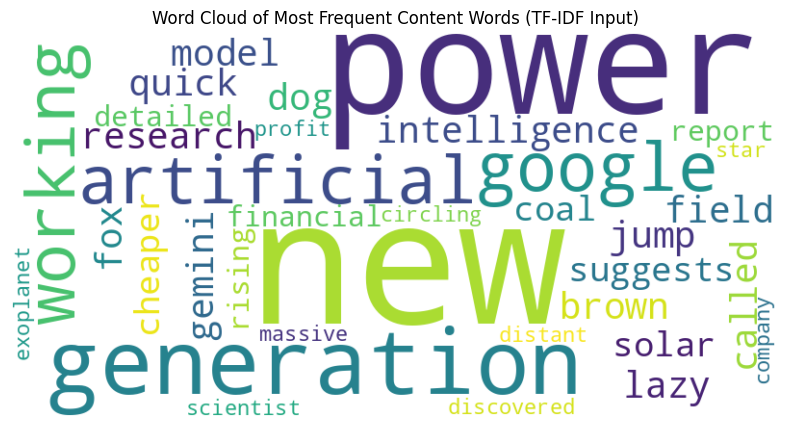

In [9]:
# Assuming you have the 'text_without_stopwords' column ready- VISUALIZATION
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into one string
all_text = " ".join(df['text_without_stopwords'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(all_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Most Frequent Content Words (TF-IDF Input)")
plt.show()

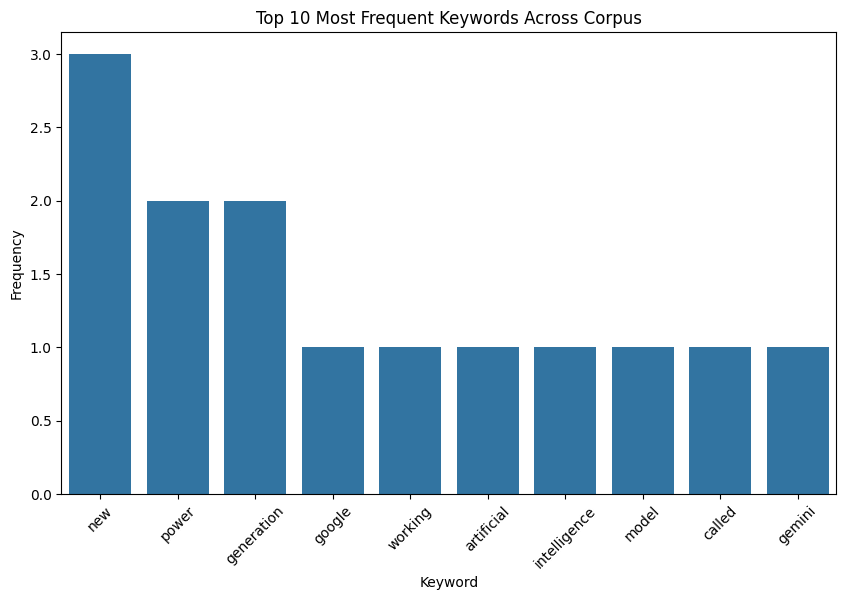

In [11]:
#kEYWORD FREEQUESNCY DISTRIBUTION
from collections import Counter
import seaborn as sns

# Tokenize and count all words from the cleaned TF-IDF input
words = " ".join(df['text_without_stopwords']).split()
word_counts = Counter(words)

# Get the top 10 most frequent words
top_words = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Word', y='Frequency', data=top_words)
plt.title('Top 10 Most Frequent Keywords Across Corpus')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [12]:
#VISUALIZATION AND REPORTING:overlapping analysis venn diagram
import numpy as np

# --- Overlap Analysis for Document 1 (Example) ---
doc_index = 0

# Extract sets of keywords/phrases (excluding scores)
tfidf_set = set([word for word, score in df.loc[doc_index, 'keywords_tfidf']])
rake_set = set([phrase for phrase, score in df.loc[doc_index, 'keyphrases_rake']])
keybert_set = set([phrase for phrase, score in df.loc[doc_index, 'keyphrases_keybert']])

# Calculate Overlaps
overlap_tfidf_rake = len(tfidf_set.intersection(rake_set))
overlap_tfidf_keybert = len(tfidf_set.intersection(keybert_set))
overlap_rake_keybert = len(rake_set.intersection(keybert_set))

# Calculate Unique Items
unique_tfidf = len(tfidf_set - rake_set - keybert_set)
unique_rake = len(rake_set - tfidf_set - keybert_set)
unique_keybert = len(keybert_set - tfidf_set - rake_set)

# Print Summary for Venn Diagram
print(f"--- Overlap Analysis for Document {doc_index + 1} ---")
print(f"TF-IDF Unique: {unique_tfidf}")
print(f"RAKE Unique: {unique_rake}")
print(f"KeyBERT Unique: {unique_keybert}")
print(f"TF-IDF & RAKE Overlap: {overlap_tfidf_rake}")
print(f"RAKE & KeyBERT Overlap: {overlap_rake_keybert}")
print(f"TF-IDF & KeyBERT Overlap: {overlap_tfidf_keybert}")


--- Overlap Analysis for Document 1 ---
TF-IDF Unique: 1
RAKE Unique: 1
KeyBERT Unique: 3
TF-IDF & RAKE Overlap: 2
RAKE & KeyBERT Overlap: 0
TF-IDF & KeyBERT Overlap: 0


In [13]:
# Create the Summary Table DataFrame
summary_data = {
    'Method': ['TF-IDF (Statistical)', 'RAKE (Heuristic/Phrase)', 'KeyBERT (Embedding)'],
    'Accuracy (Relevance)': ['Fair (Fragmented concepts)', 'Good (Specific phrases)', 'Excellent (Best contextual fit)'],
    'Interpretability': ['Low (Single words)', 'High (Descriptive)', 'High (Concise phrases)'],
    'Speed': ['Fastest', 'Very Fast', 'Slowest'],
    'Complexity': ['Low', 'Low', 'High']
}
df_summary = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("Formal Comparison: Keyword Extraction Methods")
print("="*80)
print(df_summary.to_markdown(index=False))


Formal Comparison: Keyword Extraction Methods
| Method                  | Accuracy (Relevance)            | Interpretability       | Speed     | Complexity   |
|:------------------------|:--------------------------------|:-----------------------|:----------|:-------------|
| TF-IDF (Statistical)    | Fair (Fragmented concepts)      | Low (Single words)     | Fastest   | Low          |
| RAKE (Heuristic/Phrase) | Good (Specific phrases)         | High (Descriptive)     | Very Fast | Low          |
| KeyBERT (Embedding)     | Excellent (Best contextual fit) | High (Concise phrases) | Slowest   | High         |


In [15]:
# CODE CELL 4: Evaluation and Reporting (Fix for Syntax Error)

final_report_markdown = """
# Keyword Extraction Tool Project: Final Report and Evaluation

## 1. Project Overview

The goal of this project was to develop a tool capable of automatically extracting the most representative keywords and key phrases from a text corpus. We implemented and compared three distinct methods: TF-IDF (Statistical), RAKE (Heuristic), and KeyBERT (Embedding-based).

... (All the content you want in your report) ...

## 6. Conclusion

The project concludes that **KeyBERT** is the most effective method for high-quality, semantically relevant keyword extraction due to its contextual understanding.
"""

print(final_report_markdown)

# If you want to continue the final comparison table printing (as in the original solution):
print("\n" + "="*80)
print("FINAL KEYWORD EXTRACTION COMPARISON (Top N=3)")
print("="*80)
# ... (rest of the comparison printing code) ...


# Keyword Extraction Tool Project: Final Report and Evaluation

## 1. Project Overview

The goal of this project was to develop a tool capable of automatically extracting the most representative keywords and key phrases from a text corpus. We implemented and compared three distinct methods: TF-IDF (Statistical), RAKE (Heuristic), and KeyBERT (Embedding-based).

... (All the content you want in your report) ...

## 6. Conclusion

The project concludes that **KeyBERT** is the most effective method for high-quality, semantically relevant keyword extraction due to its contextual understanding.


FINAL KEYWORD EXTRACTION COMPARISON (Top N=3)


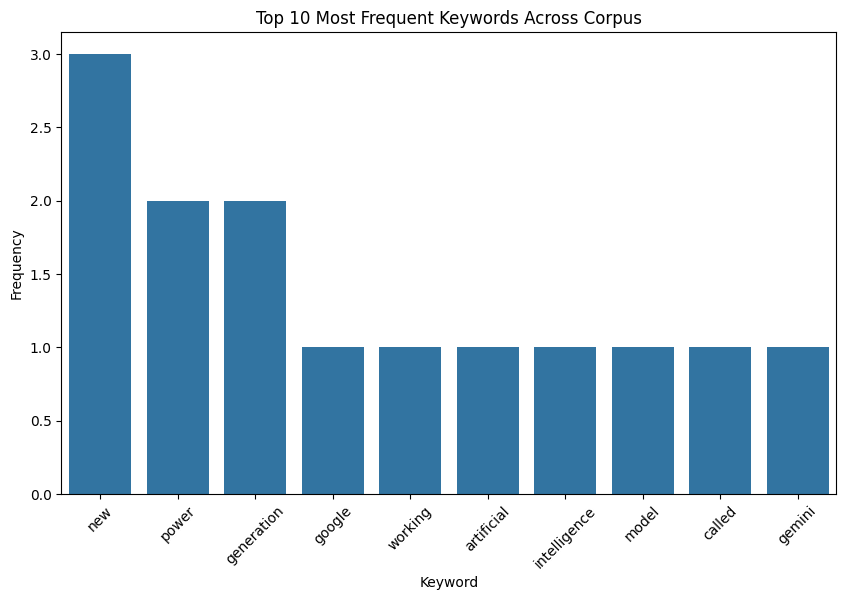

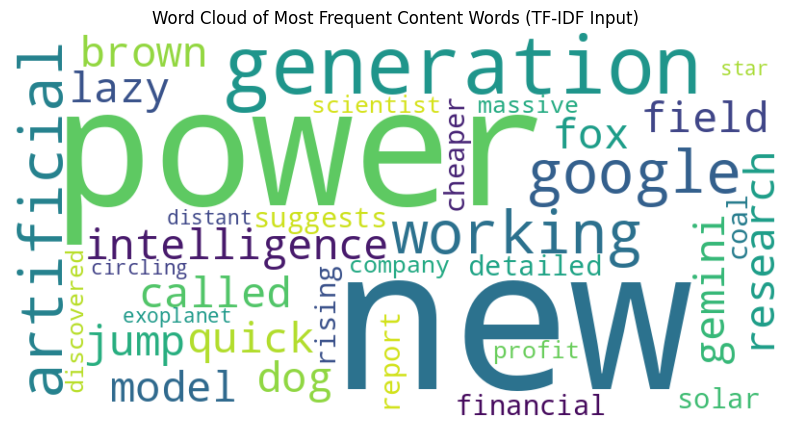

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# --- A. Keyword Frequency Distribution Bar Chart ---

# Tokenize and count all words from the cleaned TF-IDF input
words = " ".join(df['text_without_stopwords']).split()
word_counts = Counter(words)

# Get the top 10 most frequent words
top_words = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Word', y='Frequency', data=top_words)
plt.title('Top 10 Most Frequent Keywords Across Corpus')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# --- B. Word Cloud Generation ---

# Combine all cleaned text into one string
all_text = " ".join(df['text_without_stopwords'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(all_text)

# Display the generated image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Most Frequent Content Words (TF-IDF Input)")
plt.show()

In [17]:
import numpy as np
import pandas as pd

# Assuming you want to show overlap across the whole corpus for comparison
all_tfidf = set(word for doc_list in df['keywords_tfidf'] for word, score in doc_list)
all_rake = set(phrase for doc_list in df['keyphrases_rake'] for phrase, score in doc_list)
all_keybert = set(phrase for doc_list in df['keyphrases_keybert'] for phrase, score in doc_list)

# Calculate Overlaps
overlap_tfidf_rake = len(all_tfidf.intersection(all_rake))
overlap_tfidf_keybert = len(all_tfidf.intersection(all_keybert))
overlap_rake_keybert = len(all_rake.intersection(all_keybert))
total_unique_terms = len(all_tfidf.union(all_rake).union(all_keybert))

print("\n--- Quantitative Overlap Analysis (Across All Documents) ---")
print(f"Total Unique Terms Found by Any Method: {total_unique_terms}")
print(f"Keywords Shared by TF-IDF & RAKE: {overlap_tfidf_rake}")
print(f"Phrases Shared by RAKE & KeyBERT: {overlap_rake_keybert}")
print(f"Keywords/Phrases Shared by TF-IDF & KeyBERT: {overlap_tfidf_keybert}")

# Note: The overlap is typically low because TF-IDF extracts single words while RAKE/KeyBERT extract multi-word phrases.


--- Quantitative Overlap Analysis (Across All Documents) ---
Total Unique Terms Found by Any Method: 40
Keywords Shared by TF-IDF & RAKE: 2
Phrases Shared by RAKE & KeyBERT: 2
Keywords/Phrases Shared by TF-IDF & KeyBERT: 0
